In [ ]:
!pip install transformers==4.41.1
!pip install -U \
  peft==0.10.0 \
  trl==0.8.1 \
  accelerate==0.31.0

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
model_name = "IRIIS-RESEARCH/GPT2_Nepali_124M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


In [3]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [4]:
model_eos_id = model.config.eos_token_id
tokenizer_eos_id = tokenizer.eos_token_id

if model_eos_id == tokenizer_eos_id:
    print(f"Model and tokenizer EOS token IDs match: {model_eos_id}")
else:
    print(f"Mismatch detected! Model ID: {model_eos_id}, Tokenizer ID: {tokenizer_eos_id}")


Mismatch detected! Model ID: 50256, Tokenizer ID: 2


In [5]:
print(model.config.pad_token_id)

None


In [8]:
special_tokens = {
    'additional_special_tokens': [
        '#प्रेम#', '#दर्शन#', '#बिछोड#', '#देश#', '#रमाइलो#', '#दिव्य#', '#सकियो#'
    ]
}
num_added = tokenizer.add_special_tokens(special_tokens)
print(f"Tokens added: {num_added}, tokenizer size: {len(tokenizer)}")

# Resize embeddings only if tokenizer grew
if num_added > 0:
    model.resize_token_embeddings(len(tokenizer))

# Confirm
for tok in special_tokens:
    print(tok, tokenizer.convert_tokens_to_ids(tok))

print("Model vocab size:", model.config.vocab_size)


Tokens added: 0, tokenizer size: 50263
additional_special_tokens 3
Model vocab size: 50263


In [9]:
from transformers import DataCollatorForLanguageModeling

model.config.bos_token_id = tokenizer.bos_token_id
model.config.eos_token_id = tokenizer.eos_token_id

# Use EOS as pad, but mask it properly in training
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id

# The DataCollator will handle masking pad tokens in loss calculation
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

In [10]:
for token in special_tokens['additional_special_tokens']:
    token_id = tokenizer.convert_tokens_to_ids(token)
    if token_id == tokenizer.unk_token_id:
        print(f"{token} → NOT in vocab yet")
    else:
        print(f"{token} → ID {token_id}")

#प्रेम# → ID 50256
#दर्शन# → ID 50257
#बिछोड# → ID 50258
#देश# → ID 50259
#रमाइलो# → ID 50260
#दिव्य# → ID 50261
#सकियो# → ID 50262


In [ ]:
from datasets import load_dataset

# Load with streaming enabled
dataset = load_dataset(
    "csv", 
    data_files="/kaggle/input/synthetic-lyrics/lyrics_merged.csv",
    streaming=True
)

# For streaming datasets, use take() and skip() for train/val split
# Calculate split point (85% train, 15% val)
total_size = 7847  # full dataset size
train_size = int(0.85 * total_size)  # 6800

# Create train dataset (first 85%)
train_dataset = dataset["train"].take(train_size)

# Create validation dataset (last 15%)
eval_dataset = dataset["train"].skip(train_size)

# IMPORTANT: Shuffle train dataset with buffer
train_dataset = train_dataset.shuffle(seed=42, buffer_size=1000)

# Don't shuffle eval_dataset to keep validation consistent


IterableDataset({
    features: Unknown,
    num_shards: 1
})

Maximum tokens in a single row: 395


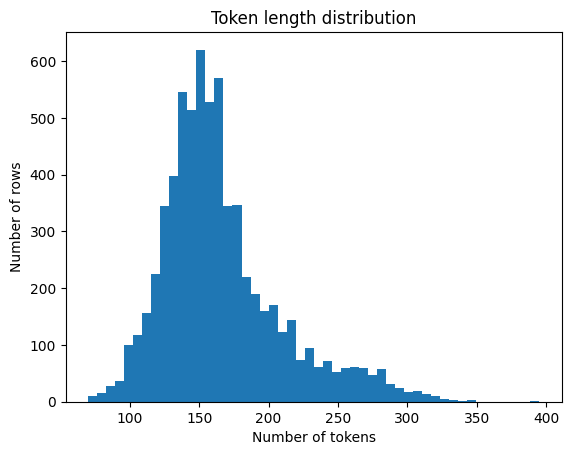

In [15]:
# Example with train_dataset
token_lengths = [len(tokenizer(text)["input_ids"]) for text in train_dataset["text"]]
max_tokens = max(token_lengths)
print("Maximum tokens in a single row:", max_tokens)


import matplotlib.pyplot as plt

plt.hist(token_lengths, bins=50)
plt.xlabel("Number of tokens")
plt.ylabel("Number of rows")
plt.title("Token length distribution")
plt.show()

In [19]:
def tokenize_fn(examples):
    # Add #सकियो# token to each text sample
    texts_with_end = [text + "#सकियो#" for text in examples["text"]]
    
    return tokenizer(
        texts_with_end,
        truncation=True,
        max_length=400,
        padding=True,
        return_overflowing_tokens=False,
    )

train_dataset = train_dataset.map(tokenize_fn, batched=True)
eval_dataset = eval_dataset.map(tokenize_fn, batched=True)

In [21]:
# To inspect examples, iterate and take first few
print("Inspecting first 3 examples:")
for i, example in enumerate(train_dataset):
    if i >= 2:  # Stop after 3 examples
        break
    
    print(f"\n--- Example {i} ---")
    print("Input IDs:", example["input_ids"][:20], "...")  # Show first 20 tokens
    print("Decoded:", tokenizer.decode(example["input_ids"][:100], skip_special_tokens=False))
    print("Full length:", len(example["input_ids"]))

Inspecting first 3 examples:

--- Example 0 ---
Input IDs: [50258, 9718, 731, 19711, 561, 8474, 24724, 26508, 8, 260, 11229, 23904, 1293, 31418, 586, 842, 22021, 5318, 17469, 35] ...
Decoded: #बिछोड# निशानी भेटिए पनि किनारमा स्पर्शको
कसरी छुट्याउने त्यो प्यास हो कि पिरतीको बोझ?
समयको गतिमा बगेको त्यो अनायास बहाव,
अन्त्यमा भेट्टाउँछ आफैँलाई रित्तो भीडको माझ।

एउटा अनिश्चितता छ हरेक साँझको छायाँमा,
जहाँ सम्झनाहरू बस्छन् एकान्त सहरको रूप लिएर।
आफ्नै धड्कनको मधुरो आवाज सुन्नु पर्छ,
जसले बाँधेको छ यो मनलाई पुरानो वाचाको घाउ दिएर।

यो कस्तो सङ्घर्ष हो, जहाँ त्याग बिना नै तृष्णा मेटिन्छ?
Full length: 350

--- Example 1 ---
Input IDs: [50259, 2722, 31349, 29686, 25675, 8, 6164, 477, 662, 5785, 5240, 499, 268, 17594, 19656, 8, 1405, 7136, 477, 49691] ...
Decoded: #देश# वीर गाथा शिरमा सजिएको
भूमिको यो गौरव कहिल्यै नझुकोस्।
पुर्खाको रगतले सिँचेको माटो,
एकताको सूत्र कहिल्यै नटुुुुुटोस्।
हिमालझैं अडिग हाम्रो साहस,
पहिचान अटल, मनमा शान्ति रहोस्।

स्वभिमानको दीप बल्छ छातीमा,
पौरखले लेखेको इतिहास हो य

In [ ]:
lyric = """बाटोमा छरिएका मान्छेका अनुहार,
आफ्नै छायाले घेरिएका ती जीवन, केवल प्रश्नभित्र लुकेका छन् ।
सत्यको खोजीमा हिँड्ने मान्छेको कथा, व्यथामा लुकेको एउटा झिल्को,
अन्धकारको सागरमा बगेको यो संसार,
कहिलेकाहीँ लाग्छ सपनाको रङ फेरिन्छ,
हरेक मोडमा नयाँ नयाँ सपना बुनिन्छ


यो क्षणभरको कथा सुन्दा लाग्छ, जीवनको अर्थ यही हो  ।


इतिहासमा हरेक पाइलामा नयाँ बिम्बहरू भेटिन्छन्,
आत्माको परिभाषा नै फेरिएको छ,
समयको चाल बुझेर निर्णय गर्ने क्षमता पनि उस्तै छ यहाँ
समयले दिएको बाटो पछ्याउँछ
समयको चाल बुझ्न सक्ने धैर्य चाहिन्छ
भविष्यलाई"""

# Tokenize the lyric
tokens = tokenizer.encode(lyric, add_special_tokens=True)
num_tokens = len(tokens)
print(num_tokens)


In [ ]:
# Generate text
input_text = "नभेटेको भए"
inputs = tokenizer(input_text, return_tensors="pt", return_token_type_ids=False)
inputs = {k: v.to(device) for k, v in inputs.items()}
outputs = model.generate(
    **inputs,
    do_sample=True,
    top_k=20,
    top_p=0.95,
    temperature=0.8,
    repetition_penalty=1.2,
    eos_token_id=tokenizer.eos_token_id,  # explicitly stop at EOS
    max_new_tokens = 400,
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("Generated text:", generated_text)

In [22]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    # num_train_epochs=10,
    max_steps=17000,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    
    logging_dir="./logs",
    report_to="tensorboard",
    logging_steps=50,
    
    eval_strategy="steps",
    eval_steps=300,
    save_strategy="steps",
    save_steps=300,
    save_total_limit=3,
    
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    
    warmup_steps=100,
    learning_rate=2e-5,
    weight_decay=0.01,
    
    fp16=True,


    optim="adamw_torch",  #Standard optimizer
    max_grad_norm=1.0,  #Gradient clipping
)

In [27]:
# Add early stopping callback
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]  # Stop if no improvement for 3 epochs
)

/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
max_steps is given, it will override any value given in num_train_epochs


In [ ]:
eval_results = trainer.evaluate()
trainer.log_metrics("eval", eval_results)
trainer.save_metrics("eval", eval_results)

In [28]:
torch.cuda.empty_cache()

In [29]:
trainer.train()
# Save the best model (automatically loaded because load_best_model_at_end=True)
trainer.save_model("./best_model")

# Save the tokenizer
tokenizer.save_pretrained("./best_model")

# Optional: Save training state
trainer.state.save_to_json("./best_model/trainer_state.json")

print("Best model and tokenizer saved to ./best_model")

log = trainer.state.log_history
import json

with open("train_logs.json", "w") as f:
    json.dump(log, f, indent=2)

Step,Training Loss,Validation Loss
300,4.885200,4.681085
600,4.617800,4.437771
900,4.427500,4.309487
1200,4.354900,4.219625
1500,4.232100,4.151202
1800,4.203200,4.095127
2100,4.152800,4.047375
2400,4.140700,4.007465
2700,4.081900,3.970916
3000,4.032700,3.937575


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Best model and tokenizer saved to ./best_model


In [52]:
# Generate text
model_name = "/kaggle/working/best_model"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to("cuda")
input_text = """भिडमा हेर्दा देखिएका मुहार,
हाँसोको गुञ्जन, हाँसोले बुनेका रङ्ग।
घाम अस्ताउँदाको त्यो क्षण,
खुसीको रंग बोकी, मुस्कुराउँदाका क्षण।
कहिलेकाहीँ हाँसेर जाँदा पनि,"""
inputs = tokenizer(input_text, return_tensors="pt", return_token_type_ids=False)
inputs = {k: v.to("cuda") for k, v in inputs.items()}

outputs = model.generate(
    **inputs,
    do_sample=True,
    top_k=20,
    top_p=0.95,
    temperature=0.8,
    repetition_penalty=1.2,
    eos_token_id=tokenizer.eos_token_id,  # explicitly stop at EOS
    max_new_tokens = 400,
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(generated_text)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


भिडमा हेर्दा देखिएका मुहार,
हाँसोको गुञ्जन, हाँसोले बुनेका रङ्ग।
घाम अस्ताउँदाको त्यो क्षण,
खुसीको रंग बोकी, मुस्कुराउँदाका क्षण।
कहिलेकाहीँ हाँसेर जाँदा पनि,
जीवनको यात्रामा, खुशी बाँड्दै जाँदा पनि।
अनायासै मायाले, फेरि भेट्छु,
खुसी बाँड्न खोज्दा पनि, मनभित्र एउटा नयाँ लहर।

सपनाहरू बुन्दै गर्दा, जिन्दगीको बाटो अर्कै छ,
नयाँ सपना बुन्दा पनि, हरेक बिहानमा छाइरहन्छु।
यो पल सधैँभरि रहोस् अब,
सम्बन्धले गाँस्ने ठाउँ देओस् यो, सधैं। सँगै बसौँ, साथमा हिँडौँ यो संसार,
यो प्रेमको बन्धन कहिल्यै नटुङ्गियोस् अब,
जीवनको यात्रामा हामी मिलेर अगाडि बढौँला।
आँखाको इशारा र बोलीमा लुकेको भाव,
मन खोलेर सुन्न खोज्छु म एक्लै।
फेरि भेट्ने वाचा गर्दै, हात समाई हिँड्छु।
यो भेटको आभास हरेक पल,
पुरानो याद बोकेर, मनमा सजाऔँला,
जहाँ भेट भयो त्यहीँ हाम्रो जिन्दगी बित्छ। एउटै डुङ्गामा घुमेको,
खुशी बाँड्ने बहाना मिल्यो यो मन। नै हो जीवन, यही हो, हाम्रो सहारा। छ एक अर्कालाई, हर श्वासले स्वागत गरौँ,
यही नै हो जीवनको आधार। बन्यो अमूल्य साथ,
जीवनमा खुसी छायोस्, साथ दिइरहोस्। बनोस् यो माया, सधैं रहिरहोस् यो मन,
जीवनभर यस

In [ ]:
eval_results_final = trainer.evaluate()
print(eval_results_final)

In [ ]:
log = trainer.state.log_history
import json

with open("train_logs.json", "w") as f:
    json.dump(log, f, indent=2)

In [ ]:
import json
import pandas as pd

# Load log history
with open("/kaggle/working/train_logs.json", "r") as f:
    log_history = json.load(f)

# Convert to DataFrame
df_logs = pd.DataFrame(log_history)
df_logs.head()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Plot training loss
if 'loss' in df_logs.columns:
    plt.plot(df_logs['step'], df_logs['loss'], label='train_loss')

# Plot evaluation loss
if 'eval_loss' in df_logs.columns:
    plt.plot(df_logs['step'], df_logs['eval_loss'], label='eval_loss')

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training & Evaluation Loss")
plt.legend()
plt.grid(True)
plt.show()


